In [1]:
#imports and config
modules = ['torch.', 'torchvision', 'sklearn', 'matplotlib.', 'seaborn','numpy','pandas']

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

device = torch.device ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")


LATENT_DIM=64
BATCH_SIZE=64
LR=0.0002
EPOCHS=30
IMAGE_SIZE=28

Using: cuda


In [2]:
#Load MNIST Data
transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
])

dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

loader = DataLoader(dataset, batch_size=BATCH_SIZE,shuffle=True)
print(f"Using: {device}")

Using: cuda


In [3]:
#generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(LATENT_DIM, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, IMAGE_SIZE * IMAGE_SIZE),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z).view(-1, 1, IMAGE_SIZE, IMAGE_SIZE)

In [4]:
#discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(IMAGE_SIZE * IMAGE_SIZE, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [5]:
#test
G = Generator().to(device)
D = Discriminator().to(device)

z= torch.randn(1,LATENT_DIM).to(device)
out = G(z)
print("Generator output shape:",out.shape)

Generator output shape: torch.Size([1, 1, 28, 28])


In [6]:
#training loop
G = Generator().to(device)
D = Discriminator().to(device)

opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))
criterion = nn.BCELoss()

for epoch in range(EPOCHS):
    for real_imgs, _ in loader:
        real_imgs = real_imgs.to(device)
        batch = real_imgs.size(0)

        # --- Train Discriminator ---
        real_labels = torch.ones(batch, 1).to(device)
        fake_labels = torch.zeros(batch, 1).to(device)

        z = torch.randn(batch, LATENT_DIM).to(device)
        fake_imgs = G(z)

        loss_D = criterion(D(real_imgs), real_labels) + \
                 criterion(D(fake_imgs.detach()), fake_labels)
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()

        # --- Train Generator ---
        loss_G = criterion(D(fake_imgs), real_labels)
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()

    print(f"Epoch {epoch+1}/{EPOCHS} | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

Epoch 1/30 | D Loss: 0.3966 | G Loss: 3.5770
Epoch 2/30 | D Loss: 0.3058 | G Loss: 3.6068
Epoch 3/30 | D Loss: 0.1621 | G Loss: 3.4324
Epoch 4/30 | D Loss: 0.3369 | G Loss: 2.9741
Epoch 5/30 | D Loss: 0.4420 | G Loss: 1.4475
Epoch 6/30 | D Loss: 0.3835 | G Loss: 2.2382
Epoch 7/30 | D Loss: 0.8819 | G Loss: 8.2092
Epoch 8/30 | D Loss: 0.4499 | G Loss: 2.0802
Epoch 9/30 | D Loss: 0.5394 | G Loss: 1.8067
Epoch 10/30 | D Loss: 0.6056 | G Loss: 2.1574
Epoch 11/30 | D Loss: 0.6824 | G Loss: 2.3077
Epoch 12/30 | D Loss: 0.9187 | G Loss: 2.1797
Epoch 13/30 | D Loss: 1.0519 | G Loss: 1.2529
Epoch 14/30 | D Loss: 0.9729 | G Loss: 2.4619
Epoch 15/30 | D Loss: 1.0496 | G Loss: 2.3282
Epoch 16/30 | D Loss: 0.9660 | G Loss: 1.6996
Epoch 17/30 | D Loss: 1.0685 | G Loss: 0.7386
Epoch 18/30 | D Loss: 0.9538 | G Loss: 0.7611
Epoch 19/30 | D Loss: 1.1777 | G Loss: 2.4271
Epoch 20/30 | D Loss: 0.7561 | G Loss: 1.6025
Epoch 21/30 | D Loss: 0.7894 | G Loss: 1.6827
Epoch 22/30 | D Loss: 1.0368 | G Loss: 1.25

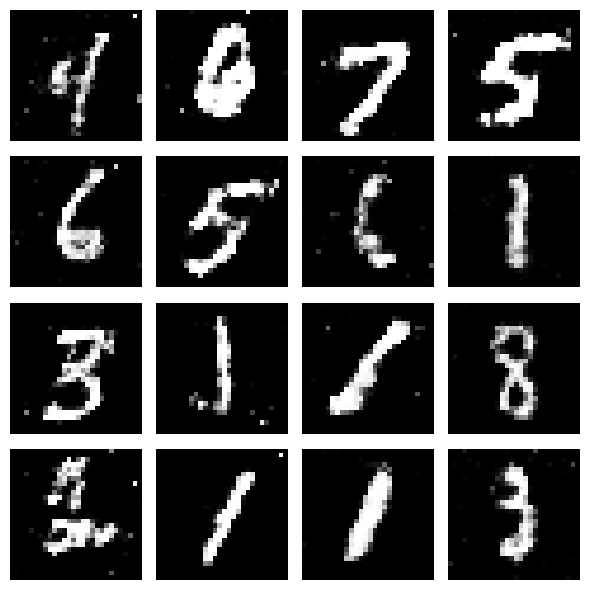

In [7]:
#view generated images
G.eval()
with torch.no_grad():
    z = torch.randn(16, LATENT_DIM).to(device)
    samples = G(z).cpu().squeeze()

fig, axes = plt.subplots(4,4, figsize=(6,6))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i], cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")
plt.tight_layout()
plt.show()